<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial05/Tutorial05_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 1: CNN Architecture & Training**

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 588kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.44MB/s]


Epoch [1/5] | Train Loss: 0.2445, Train Acc: 0.9289 | Val Loss: 0.1119, Val Acc: 0.9654
Epoch [2/5] | Train Loss: 0.0746, Train Acc: 0.9780 | Val Loss: 0.0712, Val Acc: 0.9792
Epoch [3/5] | Train Loss: 0.0511, Train Acc: 0.9846 | Val Loss: 0.0610, Val Acc: 0.9814
Epoch [4/5] | Train Loss: 0.0387, Train Acc: 0.9875 | Val Loss: 0.0629, Val Acc: 0.9819
Epoch [5/5] | Train Loss: 0.0279, Train Acc: 0.9916 | Val Loss: 0.0545, Val Acc: 0.9848


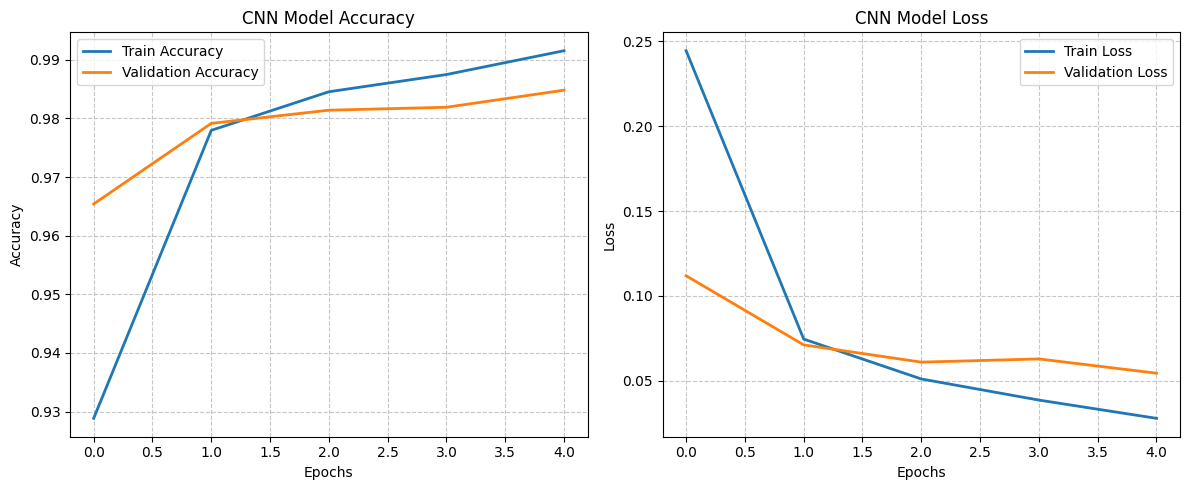

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os

# 1. Setup Directory
output_dir = "cnn_results"
os.makedirs(output_dir, exist_ok=True)

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Dataset Loading and Normalization
# transforms.ToTensor() automatically scales pixel values to [0.0, 1.0]
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create an 80/20 train/validation split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Define the CNN Architecture
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()

        # Conv2D layer: 1 input channel (grayscale), 32 output channels (filters), 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=0)
        self.relu1 = nn.ReLU()

        # MaxPooling2D layer: 2x2 pool size
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flatten layer
        self.flatten = nn.Flatten()

        # Dense (Linear) layer: 100 neurons
        # Calculation: 28x28 -> Conv(3x3) -> 26x26 -> Pool(2x2) -> 13x13.
        # 32 filters * 13 * 13 = 5408
        self.fc1 = nn.Linear(32 * 13 * 13, 100)
        self.relu2 = nn.ReLU()

        # Output layer: 10 neurons (for digits 0-9)
        self.fc2 = nn.Linear(100, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu2(x)
        x = self.fc2(x)
        return x

model = MNIST_CNN().to(device)

# 4. Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Training Loop
epochs = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    # Validation Phase
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val

    # Track metrics
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

# 6. Save Training Curves
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', linewidth=2)
plt.plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cnn_curves.png'))
plt.show()

# **Phase 2: Performance Evaluation & Visualization**

Evaluating CNN model on the test set...

Final Test Accuracy: 0.9828


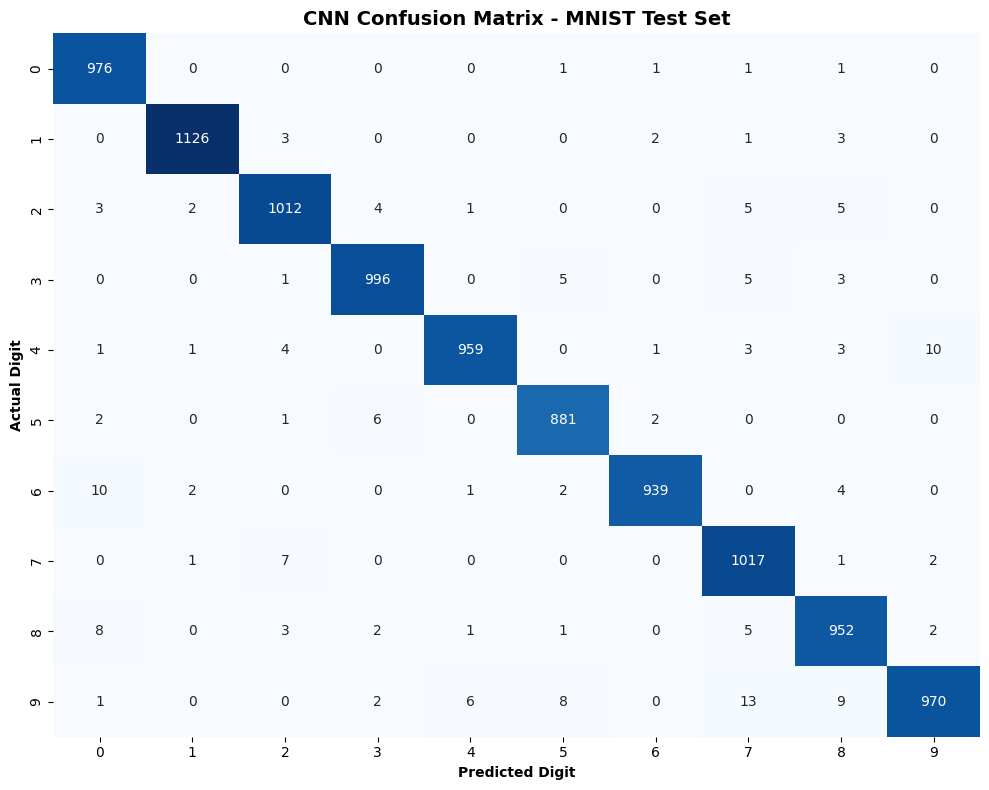

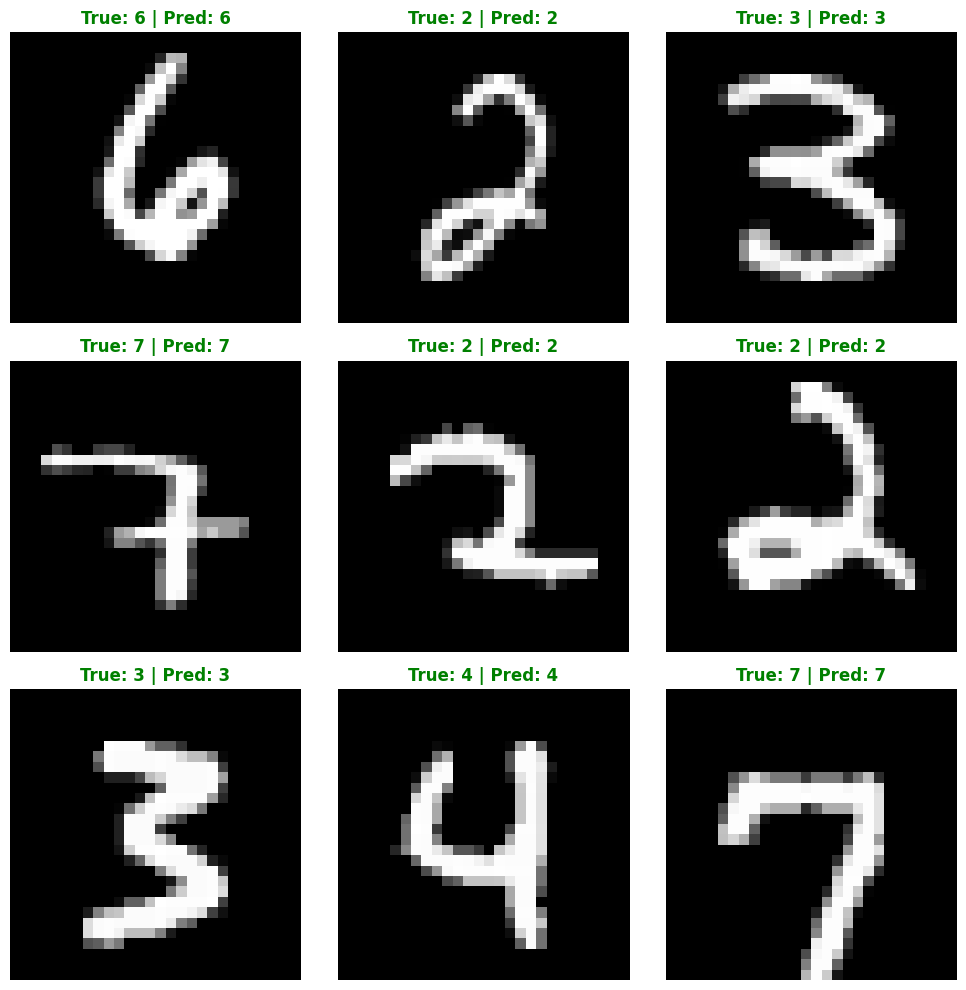


Classification Report:
               precision    recall  f1-score   support

           0     0.9750    0.9959    0.9854       980
           1     0.9947    0.9921    0.9934      1135
           2     0.9816    0.9806    0.9811      1032
           3     0.9861    0.9861    0.9861      1010
           4     0.9907    0.9766    0.9836       982
           5     0.9811    0.9877    0.9844       892
           6     0.9937    0.9802    0.9869       958
           7     0.9686    0.9893    0.9788      1028
           8     0.9704    0.9774    0.9739       974
           9     0.9858    0.9613    0.9734      1009

    accuracy                         0.9828     10000
   macro avg     0.9828    0.9827    0.9827     10000
weighted avg     0.9829    0.9828    0.9828     10000

Phase 2 Complete! Visuals and summary saved to 'cnn_results/'


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluate on Test Set
print("Evaluating CNN model on the test set...")
model.eval()

all_preds = []
all_labels = []
all_images = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs_device, labels_device = inputs.to(device), labels.to(device)

        outputs = model(inputs_device)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_images.extend(inputs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_images = np.array(all_images)

# Calculate Final Test Accuracy
test_accuracy = np.mean(all_preds == all_labels)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")

# 2. Generate and Save Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.title('CNN Confusion Matrix - MNIST Test Set', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Digit', fontweight='bold')
plt.ylabel('Actual Digit', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cnn_confusion_matrix.png'))
plt.show()

# 3. Create 3x3 Visual Prediction Grid
plt.figure(figsize=(10, 10))

# Select 9 random indices for visualization
np.random.seed(42) # For reproducible random samples
random_indices = np.random.choice(len(all_labels), 9, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)

    # Squeeze removes the channel dimension (1, 28, 28) -> (28, 28)
    img = all_images[idx].squeeze()
    true_label = all_labels[idx]
    pred_label = all_preds[idx]

    plt.imshow(img, cmap='gray')

    # Color title green if correct, red if incorrect
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label} | Pred: {pred_label}", color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cnn_predictions.png'))
plt.show()

# 4. Generate Classification Report and Save to Summary
class_report = classification_report(all_labels, all_preds, digits=4)
print("\nClassification Report:\n", class_report)

summary_path = os.path.join(output_dir, 'summary.txt')
with open(summary_path, 'w') as f:
    f.write("============================================================\n")
    f.write("TUTORIAL 5: CNN MODEL EVALUATION\n")
    f.write("============================================================\n")
    f.write("Architecture: Conv2D(32) -> MaxPool -> Dense(100) -> Output(10)\n")
    f.write(f"Final Test Accuracy: {test_accuracy:.4f}\n\n")
    f.write("Scikit-Learn Classification Report:\n")
    f.write(class_report)
    f.write("\n============================================================\n")

print(f"Phase 2 Complete! Visuals and summary saved to '{output_dir}/'")